In [16]:
pip install scikit-image

Loading Images...

Images Loaded Successfully ✅
Cats Loaded : 1000
Dogs Loaded : 1000
X Shape : (2000, 1764)
y Shape : (2000,)

Training Images : 1600
Testing Images  : 400

Training SVM Model...
Model Training Completed ✅

Model Accuracy : 71.5


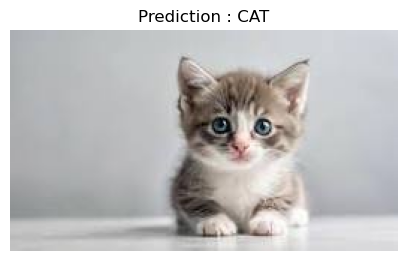


Predicted : CAT


In [18]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ==========================================
# DATASET PATH
# ==========================================

DATASET_PATH = r"C:\Users\shahf\Desktop\SCT_TASK_03\dogs-vs-cats\train\train"

# ==========================================
# SETTINGS
# ==========================================

IMG_SIZE = 64
LIMIT = 2000

X = []
y = []

print("Loading Images...")

# ==========================================
# LOAD DATASET
# ==========================================

cat_count = 0
dog_count = 0

for file in os.listdir(DATASET_PATH):

    path = os.path.join(DATASET_PATH, file)

    # ==========================
    # CAT IMAGES
    # ==========================

    if file.startswith("cat"):

        if cat_count >= LIMIT // 2:
            continue

        label = 0
        cat_count += 1

    # ==========================
    # DOG IMAGES
    # ==========================

    elif file.startswith("dog"):

        if dog_count >= LIMIT // 2:
            continue

        label = 1
        dog_count += 1

    else:
        continue

    try:
        # READ IMAGE
        img = cv2.imread(path)

        if img is None:
            continue

        # CONVERT TO GRAYSCALE
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # RESIZE IMAGE
        gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))

        # ==========================================
        # HOG FEATURE EXTRACTION
        # ==========================================

        features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            transform_sqrt=True,
            block_norm="L2-Hys"
        )

        X.append(features)

        y.append(label)

    except Exception as e:
        print("Error:", e)

    # STOP WHEN LIMIT REACHED
    if cat_count >= LIMIT // 2 and dog_count >= LIMIT // 2:
        break

# ==========================================
# DATA SUMMARY
# ==========================================

print("\nImages Loaded Successfully ✅")

print("Cats Loaded :", y.count(0))
print("Dogs Loaded :", y.count(1))

# ==========================================
# CONVERT TO NUMPY
# ==========================================

X = np.array(X)
y = np.array(y)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Images :", len(X_train))
print("Testing Images  :", len(X_test))

# ==========================================
# TRAIN SVM MODEL
# ==========================================

print("\nTraining SVM Model...")

model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

model.fit(X_train, y_train)

print("Model Training Completed ✅")

# ==========================================
# MODEL ACCURACY
# ==========================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy :", accuracy * 100)

# ==========================================
# TEST YOUR OWN IMAGE
# ==========================================

# CHANGE YOUR IMAGE PATH HERE
test_image_path = r"C:\Users\shahf\Desktop\cat.jpg"

# READ IMAGE
img = cv2.imread(test_image_path)

# CHECK IMAGE
if img is None:

    print("\nImage not found ❌")

else:

    # CONVERT IMAGE FOR DISPLAY
    display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # PREPROCESS IMAGE
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))

    # ==========================================
    # HOG FEATURES
    # ==========================================

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        transform_sqrt=True,
        block_norm="L2-Hys"
    )

    # RESHAPE
    sample = features.reshape(1, -1)

    # PREDICT
    prediction = model.predict(sample)

    classes = ["CAT", "DOG"]

    predicted_label = classes[prediction[0]]

    # ==========================================
    # SHOW IMAGE
    # ==========================================

    plt.figure(figsize=(5,5))

    plt.imshow(display_img)

    plt.title(f"Prediction : {predicted_label}")

    plt.axis("off")

    plt.show()

    print("\nPredicted :", predicted_label)